# Project 2: Predicting Sovereign Debt Crises with Deep Learning - Applying Chollet's Universal Framework

## 1. Overview

### Dataset Overview
This dataset is a curated "macro-financial" panel dataset. It combines national economic fundamentals with global market sentiment to predict whether a country will experience a Sovereign Crisis in the following year.

The data is merged from two primary sources:

* **World Bank (WDI/IDS)**: Provides "slow-moving" country-specific fundamentals (Debt-to-GDP, Inflation, Current Account Balance).

* **Federal Reserve Economic Data (FRED)**: Provides "fast-moving" global indicators (VIX Index, S&P 500, US Treasury Rates) to capture global liquidity and risk appetite.

### Binary Classification Problem
Our goal is to build a neural network that inputs 21 economic features for year $t$ and predicts the probability of a crisis in year $t+1$. 

* Features ($X$): 21 indicators (GDP growth, Debt levels, Market Volatility, etc.).
* Target ($y$): `target_next_year`
    * 0 (Stable): Normal economic conditions.
    * 1 (Crisis): Triggered by severe recession (GDP < -3%) or hyperinflation (Inflation > 50%).

### Features Descriptions 
The following is a list of official World Bank indicators and their corresponding names in the dataset.
```
wb_indicators = {
    'GC.DOD.TOTL.GD.ZS': 'debt_to_gdp',
    'DT.DOD.DECT.GN.ZS': 'external_debt_gni',
    'DT.DOD.DSTC.IR.ZS': 'short_term_debt_reserves',
    'DT.TDS.DECT.EX.ZS': 'debt_service_ratio',
    'GC.XPN.TOTL.GD.ZS': 'govt_expense_gdp',
    'FP.CPI.TOTL.ZG': 'inflation_cpi',
    'FR.INR.RINR': 'real_interest_rate',
    'FM.LBL.BMNY.ZG': 'm2_growth',
    'FM.LBL.BMNY.IR.ZS': 'm2_to_reserves',
    'FS.AST.PRVT.GD.ZS': 'private_credit_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_gdp',
    'FI.RES.TOTL.CD': 'total_reserves',
    'TT.PRI.MRCH.XD.WD': 'terms_of_trade_index',
    'NE.EXP.GNFS.ZS': 'exports_gdp',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'NY.GDP.PCAP.KD.ZG': 'gdp_pc_growth',
    'NE.GDI.FTOT.ZS': 'capital_formation_gdp'
}
```

Similarly, Federal Reserve Economic Data (FRED) official indicators and their names in the dataset.
```
fred_indicators = {
    'NASDAQCOM': 'sp500_index',
    'VIXCLS': 'vix_index',
    'DGS10': 'treasury_10y_rate',
    'FEDFUNDS': 'fed_funds_rate'
}
```

### Feature Categories
The above indicators can be grouped in categories as shown in the table below.

 Category | Key Indicators 
:--- | :---
 Growth & Stability | GDP Growth, GDP per Capita Growth, Capital Formation 
 External Vulnerability | Current Account balance, Total Reserves, Short-term Debt 
 Monetary/Prices | Inflation (CPI), M2 Growth, Real Interest Rates 
 Fiscal Health | Government Expenses, Total Debt-to-GDP 
 Global Sentiment | VIX (Volatility Index), S&P 500 Performance, Fed Funds Rate 
 Metadata | Income group, Region

### The Target
The target (0/1 labels) is the last column in the dataset, named `target_next_year`

### Metadata
Income group (`income_group`) can take any of these labels:
* LIC: low Income (GDP per capita: <$1,135)
* LMC: Lower-Middle Income (GDP per capita: $1,136 - $4,465)
* UMC: Upper-Middle Income (GDP per capita: $4,466 - $13,845)
* HIC: High Income (GDP per capita: > $13,845)

Region (`region`) can take any of these labels:
* LCN: Latin America & Caribbean. Often has high debt-to-GDP and historical crisis frequency.
* SAS: South Asia. High population density; often shows strong GDP growth but low reserves.
* SSF: Sub-Saharan Africa. Highest concentration of "Low Income" (LIC) labels; often missing debt data.
* ECS: Europe & Central Asia. Includes both "High Income" EU members and "Emerging" Balkan/Central Asian nations.
* MEA: Middle East & North Africa. Heavily influenced by oil prices (Terms of Trade index).
* EAS: East Asia & Pacific. Large manufacturing exporters; high "M2 to Reserves" ratios.
* NAC: North America. Consists primarily of USA and Canada (mostly "High Income").



## 2. Loading and Exploring the Dataset

Here is how to load the dataset.

In [21]:
import pandas as pd

In [22]:
# Load the dataset, consisting of both features and labels
# We tell pandas that 'economy' and 'year' are the index columns
df_sovereign = pd.read_csv('sovereign_dataset_v3.csv', index_col=['economy', 'year'])

print("Dataset loaded successfully!")
print(f"Total Observations: {len(df_sovereign)}")
print(f"Total Features: {len(df_sovereign.columns)}")

Dataset loaded successfully!
Total Observations: 4353
Total Features: 24


### Phase 1: Defining the Task
Here are the steps associated Chollet's universal framework that have been done for you:

* Identified the problem and collected data  
* Created labels (`target_next_year`), based on evaluation of the entire dataset identifying economic stability (0) and crisis (1)
* Provided code for basic exploratory data analysis (see below).

Here are other tasks that need to be taken care of as part of Phase 1:
* Understanding the data
    * What are the feature data types and their ranges?
    * Are there missing values? If so, how to deal with them?
    * Are the classes fairly equally represented? If not, how to account for class imbalance?
    * Are there constraints in the use of the data? For example, predicting a target at time $t+1$ should not include in the training data samples beyond $t+1$.
* Choosing a measure of success
    * Should we aim for accuracy, precision, or recall? Why?

**Your job for phase 1 is to provide answers to the questions above. In addition, you can perform any exploratory data analysis that you think would be helpful for phase 1.**

### Some Sample code
Here is some sample code to get you started with Pandas and the dataset.

In [24]:
# Select a row
# Convert to a frame to show the data type as a column
row_info = df_sovereign.loc[('ECU', 2011)].to_frame(name='Value')
row_info['Type'] = [type(v).__name__ for v in row_info['Value']]

print(f"Structure for one sample row:")
print(row_info)

Structure for one sample row:
                                     Value     Type
debt_to_gdp                            NaN  float64
external_debt_gni                20.812827  float64
short_term_debt_reserves         28.568034  float64
debt_service_ratio                9.714479  float64
govt_expense_gdp                       NaN  float64
inflation_cpi                     4.474533  float64
real_interest_rate                     NaN  float64
m2_growth                        16.618842  float64
m2_to_reserves                    9.531361  float64
private_credit_gdp               27.591549  float64
current_account_gdp              -0.506587  float64
total_reserves            2957999383.64451  float64
terms_of_trade_index                 140.0  float64
exports_gdp                      36.113369  float64
gdp_growth                        8.481477  float64
gdp_pc_growth                     6.715249  float64
capital_formation_gdp            20.941018  float64
sp500_index                    267

In [25]:
# Identify the target variable and its distribution
print("\nTarget Variable Distribution:")
print(df_sovereign['target_next_year'].value_counts())


Target Variable Distribution:
target_next_year
0.0    4028
1.0     325
Name: count, dtype: int64


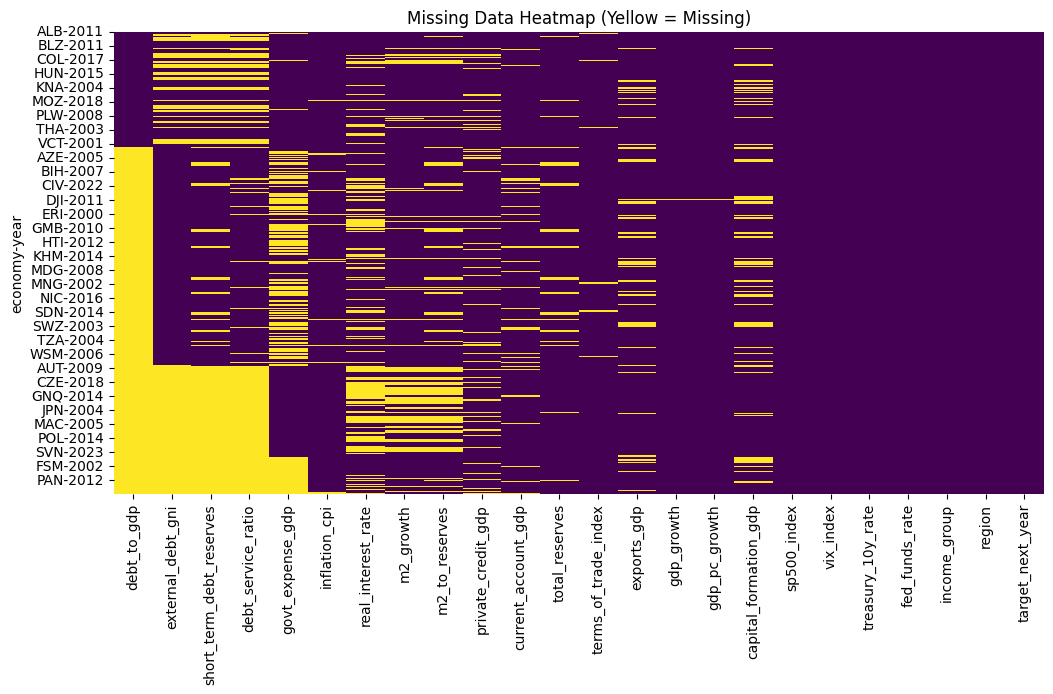

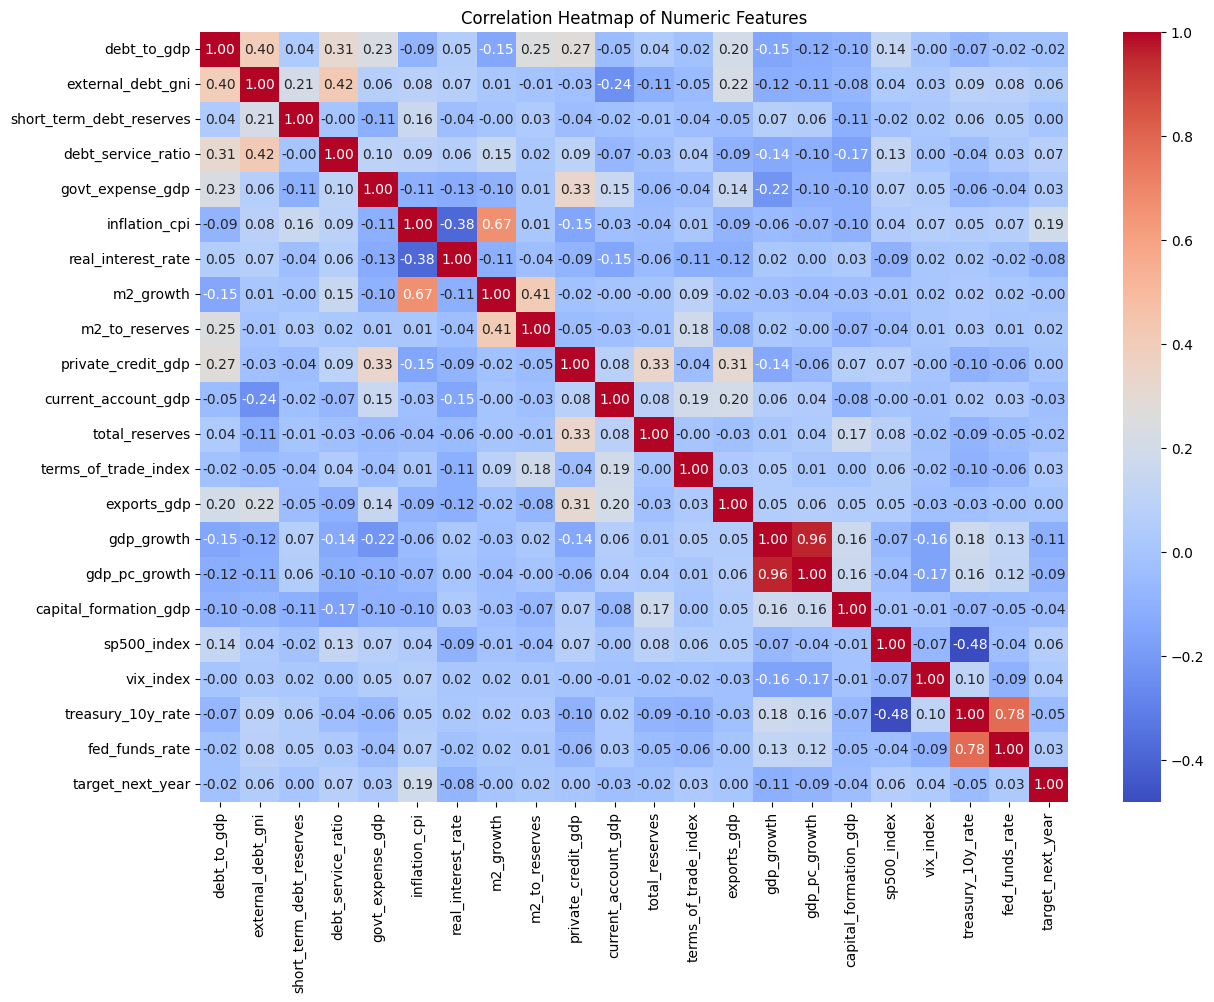

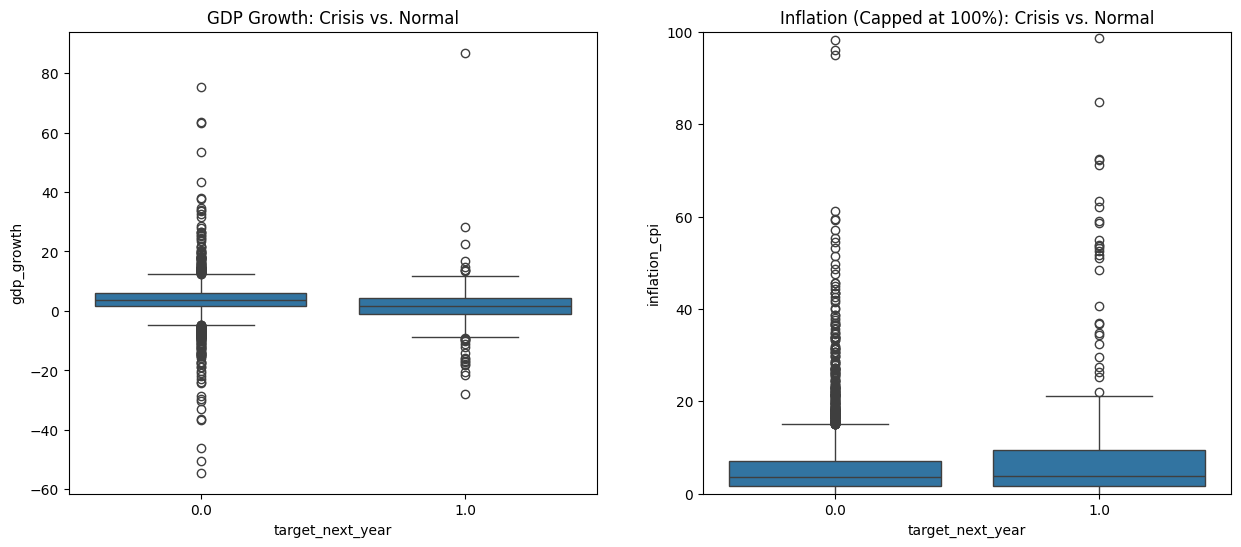

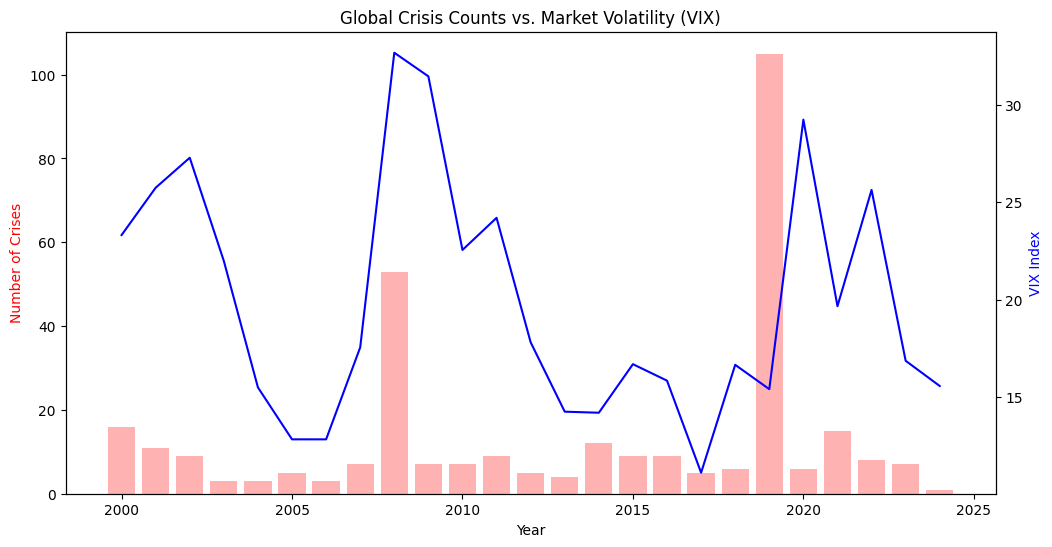

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Missing Data
# This is crucial because NNs can't handle NaNs
plt.figure(figsize=(12, 6))
sns.heatmap(df_sovereign.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap (Yellow = Missing)")
plt.show()

# Correlation Heatmap
# Which features actually move with the crisis target?
plt.figure(figsize=(14, 10))
# We only look at correlation with the target
# Ignore columns with non-numeric data for this plot
numeric_cols = df_sovereign.select_dtypes(include='number').columns
sns.heatmap(df_sovereign[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()  

# Boxplots: Comparing "Crisis" vs "Normal" Years
# Let's look at GDP Growth and Inflation (the big two)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df_sovereign, x='target_next_year', y='gdp_growth', ax=axes[0])
axes[0].set_title("GDP Growth: Crisis vs. Normal")

sns.boxplot(data=df_sovereign, x='target_next_year', y='inflation_cpi', ax=axes[1])
axes[1].set_ylim(0, 100) # Capping for visibility due to hyperinflation outliers
axes[1].set_title("Inflation (Capped at 100%): Crisis vs. Normal")
plt.show()

# Global Market Sentiment (FRED Features)
# Let's see how the VIX correlates with the total number of crises globally per year
crises_per_year = df_sovereign.groupby('year')['target_next_year'].sum()
vix_per_year = df_sovereign.groupby('year')['vix_index'].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(crises_per_year.index, crises_per_year.values, color='red', alpha=0.3, label='Global Crises Count')
ax2.plot(vix_per_year.index, vix_per_year.values, color='blue', label='Avg VIX (Market Volatility)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Crises', color='red')
ax2.set_ylabel('VIX Index', color='blue')
plt.title("Global Crisis Counts vs. Market Volatility (VIX)")
plt.show()

In [29]:
# 1. Calculate missing counts and percentages
null_counts = df_sovereign.isnull().sum()
null_pct = (df_sovereign.isnull().sum() / len(df_sovereign)) * 100

# 2. Create the summary table
missing_df = pd.DataFrame({
    'Missing Count': null_counts,
    'Percent Missing (%)': null_pct.round(2)
}).sort_values(by='Missing Count', ascending=False)

# 3. Filter to show only features with missing data
print("--- Feature Missingness Report ---")
print(missing_df[missing_df['Missing Count'] > 0])

--- Feature Missingness Report ---
                          Missing Count  Percent Missing (%)
debt_to_gdp                        3263                74.96
short_term_debt_reserves           1882                43.23
debt_service_ratio                 1744                40.06
external_debt_gni                  1633                37.51
govt_expense_gdp                   1502                34.50
real_interest_rate                 1404                32.25
m2_to_reserves                      956                21.96
m2_growth                           727                16.70
capital_formation_gdp               662                15.21
private_credit_gdp                  541                12.43
exports_gdp                         507                11.65
current_account_gdp                 308                 7.08
total_reserves                      299                 6.87
inflation_cpi                       145                 3.33
terms_of_trade_index                 89           

## 2. Develop a Model

### Evaluation protocol
Should we use hold-out validation or k-fold cross validation for this problem? Ideally, k-fold cross validation should be the standard. However, this can easily lead to data leakage and bias our models. 

Instead, use hold-out validation, splitting the data by years. For example, the training set could be 2000-2017, the validation set 2018-2020, and the test set 2021-2023.

### Prepare the data
The tasks to consider are:
* Deal with missing data, e.g., 
    * Temporal imputation: Use Forward Fill (ffill) and Backward Fill (bfill) within country groups to handle reporting gaps.

    * Hierarchical imputation: Use `region` or `income_group` medians to fill data for a country that has never reported a specific metric.

    * Feature dropping: Identify and remove variables with extreme missingness (like our 75% missing `debt_to_gdp`) that cannot be reliably salvaged.

    * Observation filtering: Remove countries or years (like 2024–2025) that lack enough features to provide a meaningful signal.

* Normalize the data. Here, it is better to normalize the training + validation sets separately from the test set to avoid data leakage. 
    * Standardization: Transform features to have a mean of 0 and a standard deviation of 1.
    * Handling skewed data: Consider applying log transforms to highly skewed variables like `inflation_cpi` or `total_reserves` to normalize the distribution and reduce the impact of extreme outliers.

### Specify a baseline
If we always guess 0 (no crisis), the accuracy will be high, ~92.5%. We would want to beat this baseline to have a meaningful model. However, accuracy is misleading in our case due the data imbalance problem. 

If we always guess 1 (crisis), we will have recall=1, but precision = 0.075. 

A third approach would be to guess 1 (crisis) at the same frequency as it occurs in the data. If so, we expect recall = 0.075. 

### Beat the baseline
Develop a small model capable of beating a simple baseline (has statistical power). By small we mean capacity. The idea is to figure out the right capacity for this problem to beat the baseline. 

### Scale up: develop a model that overfits
Now that we can beat the baseline, we can test larger models by adding layers, increase nodes per layer, train longer, etc.

### Regularize the model to combat overfitting
As we increase capacity, we will also increase the chance for overfitting. Consider applying L1, L2, and dropout. 

You may also consider feature engineering, e.g., adding a new feature, `reserve_over_ratio`, by dividing `total_reserves` by `external_debt_gni` as a proxy for `debt_to_gdp`.